<a href="https://colab.research.google.com/github/minhyuk0914/Python_Study/blob/main/Dacon/%EC%84%A0%EB%AC%BC%20%EB%B0%B0%EC%86%A1%20%EA%B2%BD%EB%A1%9C%20%EC%B5%9C%EC%A0%81%ED%99%94%20%EA%B2%BD%EC%A7%84%EB%8C%80%ED%9A%8C/ortools_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ortools

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import math
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

from scipy.spatial.distance import cdist
import itertools

import matplotlib
import matplotlib.pylab as plt
import seaborn as sns

In [ ]:
data_path = '/content/drive/MyDrive/dacon/선물_배송_경로_최적화_경진대회/open/'

df = pd.read_csv(data_path + 'data.csv')

In [ ]:
df

,point_id,x,y,demand
0,DEPOT,0,0,0
1,TOWN_01,34,94,2
2,TOWN_02,40,89,4
3,TOWN_03,39,95,1
4,TOWN_04,47,94,4
...,...,...,...,...
71,TOWN_71,89,85,6
72,TOWN_72,94,79,3
73,TOWN_73,67,58,3
74,TOWN_74,38,94,2


In [ ]:
df['locations'] = [(row['x'], row['y']) for _, row in df.iterrows()]

In [ ]:
distance_matrix = cdist(df[['x', 'y']].values, df[['x', 'y']].values, metric='euclidean')
distance_matrix = distance_matrix.astype(int)

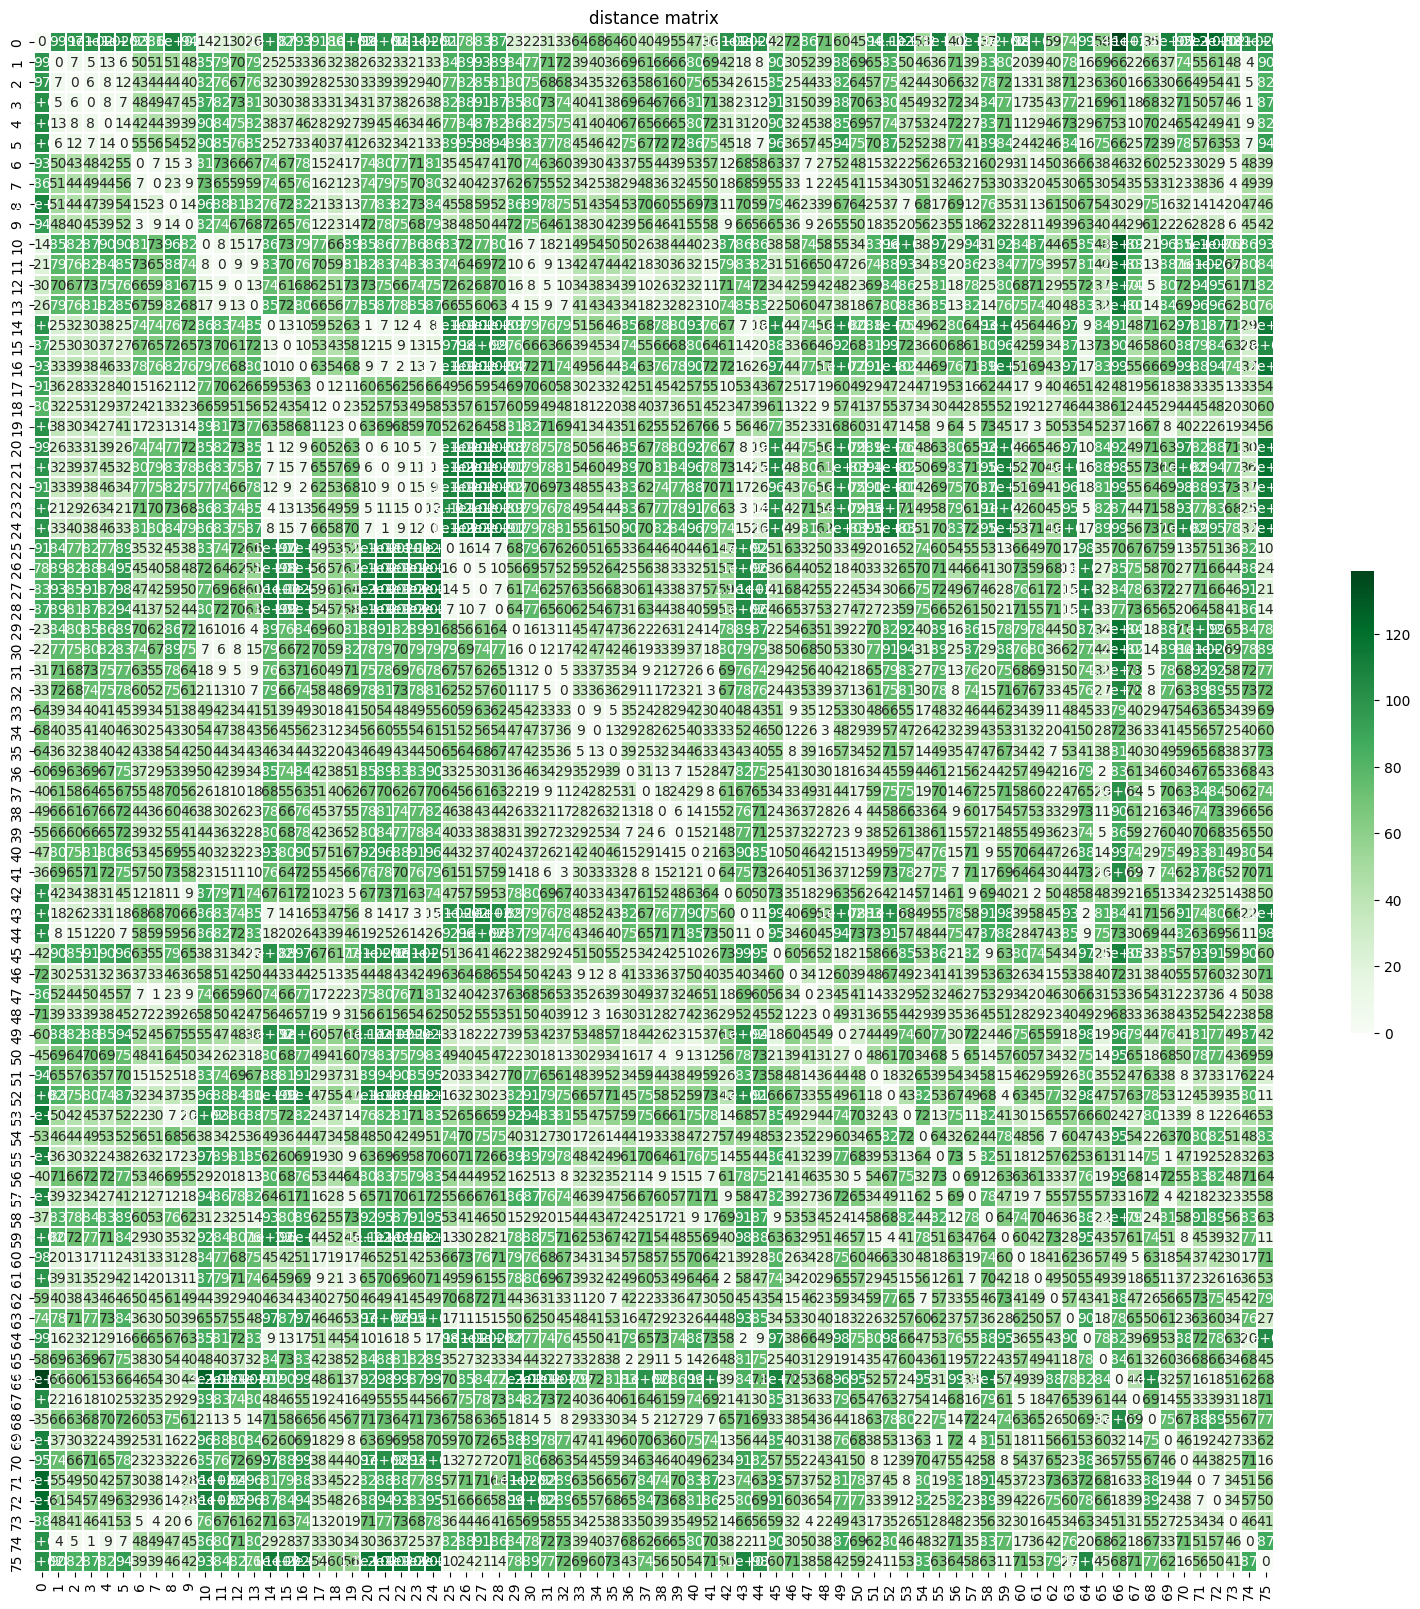

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(distance_matrix, ax=ax, cmap='Greens', annot=True, cbar=True, cbar_kws={"shrink": .3}, linewidths=.1)
plt.title('distance matrix')
plt.show()

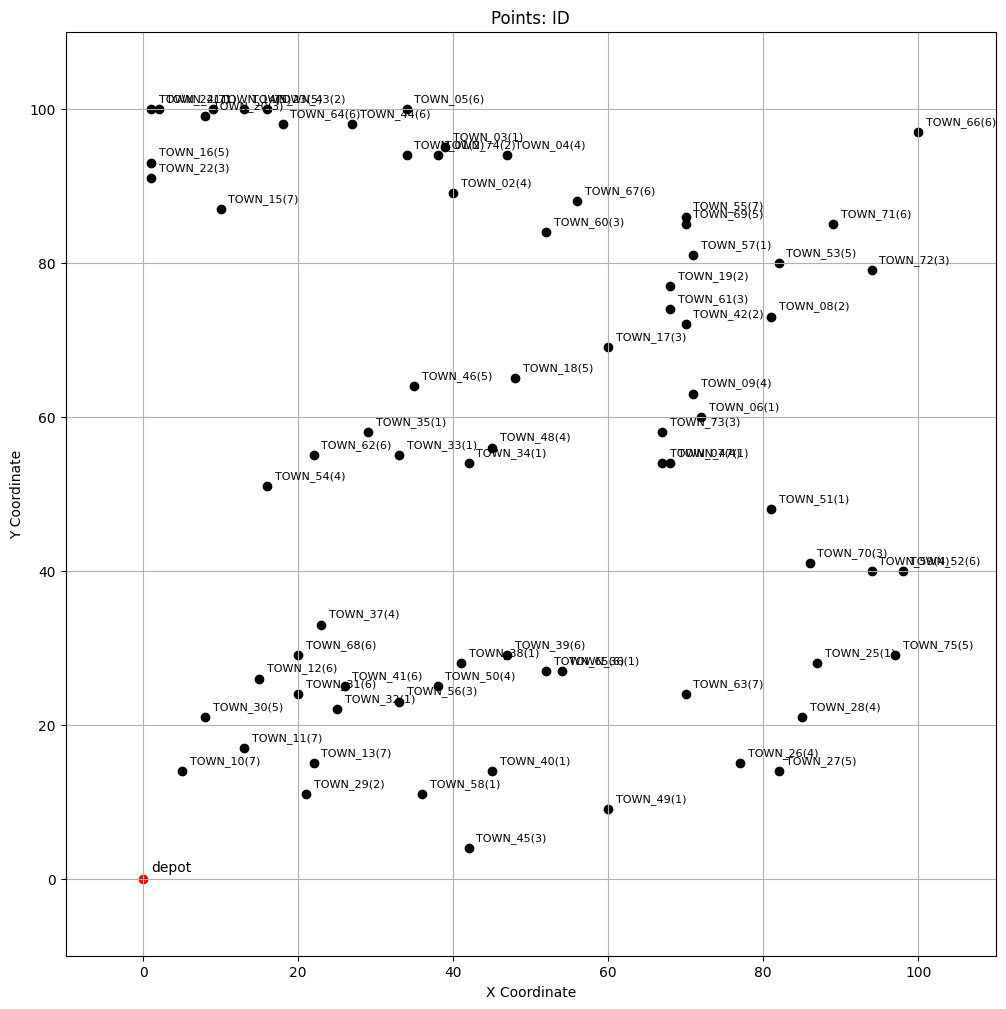

In [ ]:
plt.figure(figsize=(12, 12))

# draw problem state
for index, row in df.iterrows():
    if row['point_id'] == 'DEPOT':
        plt.scatter(row['x'], row['y'], c='red', label='Depot')
        plt.text(row['x'] + 1, row['y'] + 1, 'depot', fontsize=10)
    else:
        plt.scatter(row['x'], row['y'], c='black', label=row['point_id'])
        plt.text(row['x'] + 1, row['y'] + 1, f"{row['point_id']}({row['demand']})", fontsize=8)

plt.xlim([-10, 110])
plt.ylim([-10, 110])
plt.title('Points: ID')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

In [ ]:
df

,point_id,x,y,demand,locations
0,DEPOT,0,0,0,"(0, 0)"
1,TOWN_01,34,94,2,"(34, 94)"
2,TOWN_02,40,89,4,"(40, 89)"
3,TOWN_03,39,95,1,"(39, 95)"
4,TOWN_04,47,94,4,"(47, 94)"
...,...,...,...,...,...
71,TOWN_71,89,85,6,"(89, 85)"
72,TOWN_72,94,79,3,"(94, 79)"
73,TOWN_73,67,58,3,"(67, 58)"
74,TOWN_74,38,94,2,"(38, 94)"


In [ ]:
# 데이터 생성
# 75 : 마을의 수
data = {}
data['distance_matrix'] = distance_matrix
data['demands'] = df['demand'].tolist()
data['vehicle_capacity'] = [25] * 75
data['num_vehicles'] = 75
data['depot'] = 0

In [ ]:
# 색인 관리자, Routing Index Manager 생성
manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']),
                                       data['num_vehicles'],
                                       data['depot'])
# Routing Model 생성
routing = pywrapcp.RoutingModel(manager)


# 두 점 사이의 거리를 반환하는 함수 : 거리 콜백 함수
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

# 콜백 함수를 라우팅 모델에 등록 및 차량 간선 비용(거리) 평가자로 설정
transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# 용량 제약 추가
def demand_callback(from_index):
    from_node = manager.IndexToNode(from_index)
    return data['demands'][from_node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,  # 수요 콜백 함수
    0,                      # 초과 허용치
    data['vehicle_capacity'],  # 차량 용량
    True,                   # 경로의 용량 제약 적용 여부
    'Capacity'
)

# 탐색 파라미터 설정
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)

# search_parameters.first_solution_strategy = (routing_enums_pb2.LocalSearchMetaheuristic.TABU_SEARCH)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.TABU_SEARCH
)
search_parameters.time_limit.seconds = 60 * 60

# 문제 풀이
solution = routing.SolveWithParameters(search_parameters)


In [ ]:
if solution:
    # 해를 찾은 경우 라우트(경로) 추출
    total_distance = 0
    total_route = []
    route_distances = []  # 각 경로의 거리 저장
    total_load = 0
    for vehicle_id in range(data['num_vehicles']):
        plan_output = f"Route for vehicle {vehicle_id}:\n"

        index = routing.Start(vehicle_id)
        route = []
        route_distance = 0
        route_load = 0
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route.append(node_index)
            route_load += data['demands'][node_index]
            plan_output += f" {node_index} Load({route_load}) -> "

            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id
            )

        # 방문한 루트만 추가
        if len(route) > 1:

            # 마지막 돌아오는 것 DEPOT 추가
            route += [0]


            # 전체 정보(경로, 거리, 운반한 짐) 업데이트
            total_route.append(route)
            total_distance += route_distance
            total_load += route_load


            print("Route : ", route)
            plan_output += f" {manager.IndexToNode(index)} Load({route_load})\n"
            plan_output += f"Distance of the route: {route_distance}m\n"
            plan_output += f"Load of the route: {route_load}\n"
            print(plan_output)


    print(f"Total distance of all routes: {total_distance}m")
    print(f"Total load of all routes: {total_load}")

Route :  [0, 41, 56, 50, 39, 65, 0]
Route for vehicle 0:
 0 Load(0) ->  41 Load(6) ->  56 Load(9) ->  50 Load(13) ->  39 Load(19) ->  65 Load(25) ->  0 Load(25)
Distance of the route: 120m
Load of the route: 25

Route :  [0, 58, 40, 25, 75, 52, 59, 70, 51, 38, 29, 0]
Route for vehicle 1:
 0 Load(0) ->  58 Load(1) ->  40 Load(2) ->  25 Load(3) ->  75 Load(8) ->  52 Load(14) ->  59 Load(18) ->  70 Load(21) ->  51 Load(22) ->  38 Load(23) ->  29 Load(25) ->  0 Load(25)
Distance of the route: 224m
Load of the route: 25

Route :  [0, 32, 7, 47, 73, 9, 61, 17, 18, 34, 0]
Route for vehicle 2:
 0 Load(0) ->  32 Load(1) ->  7 Load(5) ->  47 Load(6) ->  73 Load(9) ->  9 Load(13) ->  61 Load(16) ->  17 Load(19) ->  18 Load(24) ->  34 Load(25) ->  0 Load(25)
Distance of the route: 208m
Load of the route: 25

Route :  [0, 14, 20, 21, 24, 16, 22, 0]
Route for vehicle 3:
 0 Load(0) ->  14 Load(5) ->  20 Load(8) ->  21 Load(9) ->  24 Load(16) ->  16 Load(21) ->  22 Load(24) ->  0 Load(24)
Distance of 

In [ ]:
total_route_town_ids = []

for route in total_route:
    for idx in route[:-1]:
        town_id = df.loc[idx, 'point_id']
        total_route_town_ids.append(town_id)

total_route_town_ids += ['DEPOT']

In [ ]:
submission_df = pd.DataFrame({"point_id": total_route_town_ids})

submission_df['point_id'] = total_route_town_ids

submission_df.to_csv(data_path + 'test_3.csv', index=False)

from google.colab import files
files.download(data_path + 'test_3.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
total_route_town_ids

['DEPOT',
 'TOWN_41',
 'TOWN_56',
 'TOWN_50',
 'TOWN_39',
 'TOWN_65',
 'DEPOT',
 'TOWN_58',
 'TOWN_40',
 'TOWN_25',
 'TOWN_75',
 'TOWN_52',
 'TOWN_59',
 'TOWN_70',
 'TOWN_51',
 'TOWN_38',
 'TOWN_29',
 'DEPOT',
 'TOWN_32',
 'TOWN_07',
 'TOWN_47',
 'TOWN_73',
 'TOWN_09',
 'TOWN_61',
 'TOWN_17',
 'TOWN_18',
 'TOWN_34',
 'DEPOT',
 'TOWN_14',
 'TOWN_20',
 'TOWN_21',
 'TOWN_24',
 'TOWN_16',
 'TOWN_22',
 'DEPOT',
 'TOWN_19',
 'TOWN_57',
 'TOWN_69',
 'TOWN_55',
 'TOWN_67',
 'TOWN_60',
 'TOWN_35',
 'DEPOT',
 'TOWN_02',
 'TOWN_04',
 'TOWN_03',
 'TOWN_74',
 'TOWN_01',
 'TOWN_05',
 'TOWN_44',
 'DEPOT',
 'TOWN_13',
 'TOWN_31',
 'TOWN_12',
 'TOWN_30',
 'DEPOT',
 'TOWN_54',
 'TOWN_62',
 'TOWN_33',
 'TOWN_48',
 'TOWN_37',
 'TOWN_68',
 'DEPOT',
 'TOWN_36',
 'TOWN_63',
 'TOWN_28',
 'TOWN_27',
 'TOWN_26',
 'TOWN_49',
 'TOWN_45',
 'DEPOT',
 'TOWN_42',
 'TOWN_53',
 'TOWN_71',
 'TOWN_66',
 'TOWN_72',
 'TOWN_08',
 'TOWN_06',
 'DEPOT',
 'TOWN_10',
 'TOWN_11',
 'DEPOT',
 'TOWN_46',
 'TOWN_64',
 'TOWN_43',
 'TO

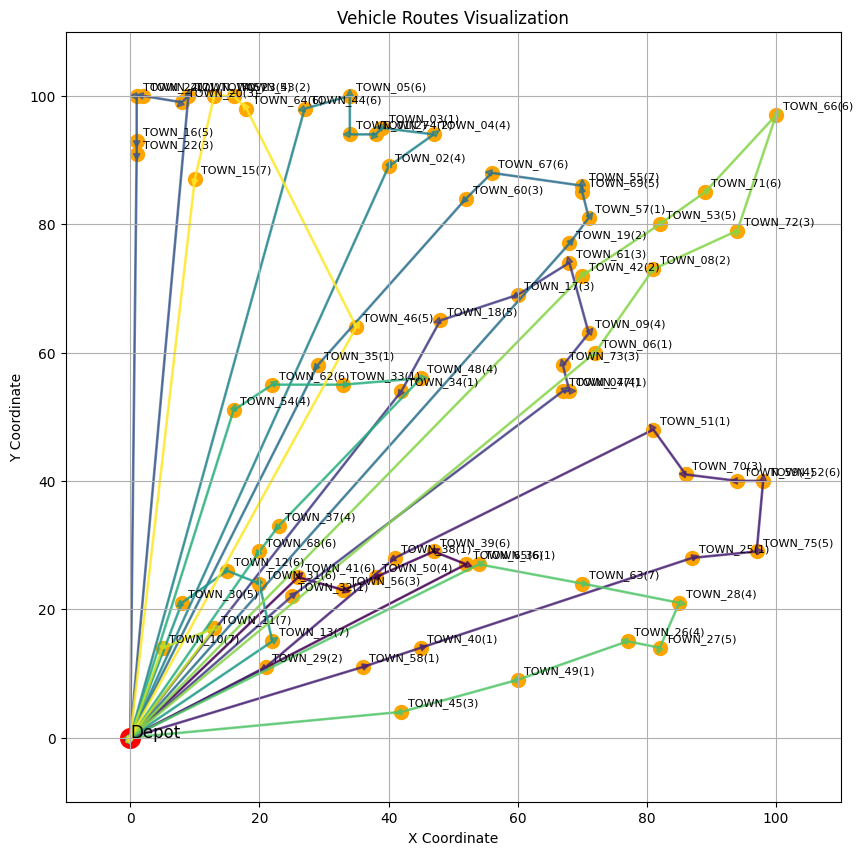

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 차량 경로 시각화
# 차량 수에 따라 색상 생성
colors = cm.viridis(np.linspace(0, 1, len(total_route)))

# 시각화: matplotlib로 플로팅
plt.figure(figsize=(10, 10))

# DEPOT과 고객 위치 표시
for index, row in df.iterrows():
    if row['point_id'] == 'DEPOT':
        plt.scatter(row['x'], row['y'], c='red', s = 200, label='Depot')
        plt.text(row['x'], row['y'], "Depot", fontsize=12)
    else:
        plt.scatter(row['x'], row['y'], c='orange', s = 100, label = row['point_id'])
        plt.text(row['x'] + 1, row['y'] + 1, f"{row['point_id']}({row['demand']})", fontsize=8)


# 차량 경로 시각화
for k in range(len(total_route)):
    route = total_route[k]
    if route:  # 경로가 존재하는 경우
        color = colors[k]  # 차량 색상 선택
        for i in range(len(route) - 1):
            start = route[i]
            end = route[i + 1]
            # 화살표 추가
            plt.arrow(df.x[start], df.y[start],
                      df.x[end] - df.x[start],
                      df.y[end] - df.y[start],
                      head_width=1, head_length=1, fc=color, ec=color, width=0.2, alpha=0.7)

# 범례 추가
plt.xlim([-10, 110])
plt.ylim([-10, 110])
plt.title('Vehicle Routes Visualization')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()


In [ ]:
import ipywidgets
from IPython.display import display

# 차량 경로 시각화
# 차량 수에 따라 색상 생성
colors = cm.viridis(np.linspace(0, 1, len(total_route)))

# DEPOT과 고객 위치 표시
def plot_route(route_index):
    plt.figure(figsize=(10, 10))

    # DEPOT과 고객 위치 표시
    for index, row in df.iterrows():
        if row['point_id'] == 'DEPOT':
            plt.scatter(row['x'], row['y'], c='red', s=200, label='Depot')
            plt.text(row['x'], row['y'], "Depot", fontsize=12)
        else:
            plt.scatter(row['x'], row['y'], c='orange', s=100, label=row['point_id'])
            plt.text(row['x'] + 1, row['y'] + 1, f"{row['point_id']}({row['demand']})", fontsize=8)

    # 선택한 차량 경로 시각화
    route = total_route[route_index]
    if route:  # 경로가 존재하는 경우
        color = colors[route_index]  # 차량 색상 선택
        for i in range(len(route) - 1):
            start = route[i]
            end = route[i + 1]
            # 화살표 추가
            plt.arrow(df.x[start], df.y[start],
                      df.x[end] - df.x[start],
                      df.y[end] - df.y[start],
                      head_width=1, head_length=1, fc=color, ec=color, width=0.2, alpha=0.7)

        # 나머지 경로 흐리게 표시
    for idx, route in enumerate(total_route):
        if idx != route_index:  # 선택된 경로가 아닌 경우
            color = colors[idx]
            for i in range(len(route) - 1):
                start = route[i]
                end = route[i + 1]
                plt.arrow(df.x[start], df.y[start],
                          df.x[end] - df.x[start],
                          df.y[end] - df.y[start],
                          head_width=1, head_length=1, fc=color, ec=color, width=0.2, alpha=0.1)  # alpha 값을 낮춰 흐리게

    plt.xlim([-10, 110])
    plt.ylim([-10, 110])
    plt.title(f'Vehicle Route Visualization for Vehicle {route_index}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

ipywidgets.interactive(plot_route, route_index = (0, len(total_route), 1))

interactive(children=(IntSlider(value=6, description='route_index', max=12), Output()), _dom_classes=('widget-…